# Capstone Session 11

This notebook is generated from the copied `Capstone_Session_11.pdf` directions and the staged `GrammarandProductReviews.xlsx` dataset.

## Objective

Build the required CNN-LSTM hybrid model to classify product reviews as positive or negative using the staged workbook data.

## Source Note

The copied PDF names `GrammarandProductReviews.csv`, but the staged source file is `GrammarandProductReviews.xlsx`. This notebook loads the workbook and exports a converted CSV artifact for the website evidence flow before training the model.

In [ ]:
from pathlib import Path
import json
import os
import sys
from urllib.parse import quote

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
tf.keras.utils.set_random_seed(42)

IS_COLAB = 'google.colab' in sys.modules
GITHUB_REPO_OWNER = 'FrancisBurnet'
GITHUB_REPO_NAME = 'francisburnet'
GITHUB_REPO_BRANCH = 'main'
CAPSTONE_ROOT = Path('Incremental Capstones/Deep Learning Specialization/Capstone Session 11')
WORKBOOK_FILENAME = 'GrammarandProductReviews.xlsx'


def build_github_url(relative_path: Path, media: bool = False) -> str:
    encoded_path = quote(relative_path.as_posix(), safe='/')
    if media:
        return (
            f"https://media.githubusercontent.com/media/{GITHUB_REPO_OWNER}/{GITHUB_REPO_NAME}/"
            f"{GITHUB_REPO_BRANCH}/{encoded_path}"
        )
    return (
        f"https://raw.githubusercontent.com/{GITHUB_REPO_OWNER}/{GITHUB_REPO_NAME}/"
        f"{GITHUB_REPO_BRANCH}/{encoded_path}"
    )


def resolve_capstone_dir() -> Path | None:
    current = Path.cwd().resolve()
    capstone_parts = CAPSTONE_ROOT.parts
    for candidate in [current, *current.parents]:
        if len(candidate.parts) >= len(capstone_parts) and candidate.parts[-len(capstone_parts):] == capstone_parts:
            return candidate
        nested_candidate = candidate / CAPSTONE_ROOT
        if nested_candidate.exists():
            return nested_candidate
    return None


CAPSTONE_DIR = resolve_capstone_dir()
WORKBOOK_URL = build_github_url(CAPSTONE_ROOT / WORKBOOK_FILENAME)

if CAPSTONE_DIR is not None:
    OUTPUT_ROOT = CAPSTONE_DIR
    OUTPUT_MODE = 'permanent capstone outputs'
    OUTPUT_DISPLAY = (CAPSTONE_ROOT / 'outputs').as_posix()
else:
    runtime_root = Path('/content/capstone-session-11-runtime') if IS_COLAB else Path.cwd().resolve() / 'capstone-session-11-runtime'
    OUTPUT_ROOT = runtime_root
    OUTPUT_MODE = 'runtime scratch outputs; export final artifacts back into the capstone outputs folder'
    OUTPUT_DISPLAY = 'capstone-session-11-runtime/outputs'

OUTPUTS_DIR = (OUTPUT_ROOT / 'outputs').resolve()
PLOTS_DIR = OUTPUTS_DIR / 'plots'
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style='whitegrid')

print('Runtime:', 'Google Colab' if IS_COLAB else 'Notebook runtime')
print('Capstone artifact path:', CAPSTONE_ROOT.as_posix())
print('Workbook source:', WORKBOOK_URL)
print('Output mode:', OUTPUT_MODE)
print('Output target:', OUTPUT_DISPLAY)

Runtime: Notebook runtime
Capstone artifact path: Incremental Capstones/Deep Learning Specialization/Capstone Session 11
Workbook source: https://media.githubusercontent.com/media/FrancisBurnet/francisburnet/main/Incremental%20Capstones/Deep%20Learning%20Specialization/Capstone%20Session%2011/GrammarandProductReviews.xlsx
Output mode: permanent capstone outputs
Output target: Incremental Capstones/Deep Learning Specialization/Capstone Session 11/outputs


In [2]:
df = pd.read_excel(WORKBOOK_URL)
converted_csv_path = OUTPUTS_DIR / 'GrammarandProductReviews_converted.csv'
df.to_csv(converted_csv_path, index=False)
df['reviews.text'] = df['reviews.text'].fillna('').astype(str)
df['target'] = (df['reviews.rating'] > 3).astype(int)
display(df[['reviews.rating', 'reviews.text', 'target']].head())
print('Workbook source used:', WORKBOOK_URL)
print('Shape:', df.shape)
print('Target distribution:', df['target'].value_counts().to_dict())

HTTPError: HTTP Error 404: Not Found

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    df['reviews.text'],
    df['target'],
    test_size=0.2,
    random_state=42,
    stratify=df['target'],
)
MAX_NB_WORDS = 20000
MAX_SEQUENCE_LENGTH = 150
tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=MAX_NB_WORDS)
tokenizer.fit_on_texts(X_train)
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)
X_train_pad = tf.keras.preprocessing.sequence.pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH)
X_test_pad = tf.keras.preprocessing.sequence.pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH)
y_train_onehot = tf.keras.utils.to_categorical(y_train, num_classes=2)
y_test_onehot = tf.keras.utils.to_categorical(y_test, num_classes=2)
print('Padded train shape:', X_train_pad.shape)
print('Padded test shape:', X_test_pad.shape)

Padded train shape: (8000, 150)
Padded test shape: (2001, 150)


In [4]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(MAX_SEQUENCE_LENGTH,), dtype='int32'),
    tf.keras.layers.Embedding(input_dim=MAX_NB_WORDS, output_dim=50, input_length=MAX_SEQUENCE_LENGTH),
    tf.keras.layers.Conv1D(64, 5, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=5),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Conv1D(64, 5, activation='relu'),
    tf.keras.layers.MaxPooling1D(pool_size=5),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(64),
    tf.keras.layers.Dense(2, activation='softmax'),
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(
    X_train_pad,
    y_train_onehot,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=0,
)
pd.DataFrame(history.history).head()

X:\SIMPLILEARN\.venv\Lib\site-packages\keras\src\layers\core\embedding.py:103: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


,accuracy,loss,val_accuracy,val_loss
0,0.913125,0.309694,0.923750,0.259024
1,0.913125,0.277587,0.923750,0.237573
2,0.928125,0.210896,0.925625,0.226740
3,0.946406,0.154717,0.927500,0.251219
4,0.964375,0.107533,0.922500,0.295029


In [5]:
test_probabilities = model.predict(X_test_pad, verbose=0)
test_predictions = np.argmax(test_probabilities, axis=1)
test_loss, test_accuracy = model.evaluate(X_test_pad, y_test_onehot, verbose=0)
print('Test loss:', round(float(test_loss), 4))
print('Test accuracy:', round(float(test_accuracy), 4))
print('Sklearn accuracy:', round(float(accuracy_score(y_test, test_predictions)), 4))

Test loss: 0.2893
Test accuracy: 0.92
Sklearn accuracy: 0.92


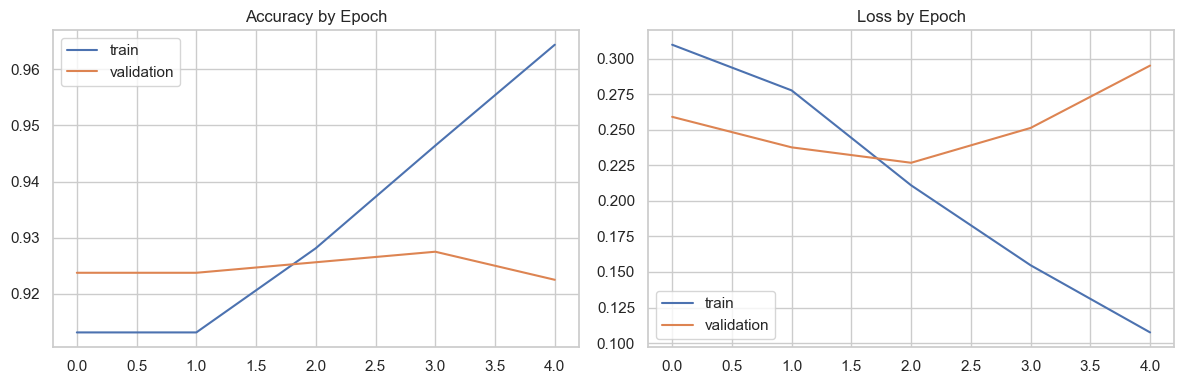

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['accuracy'], label='train')
axes[0].plot(history.history['val_accuracy'], label='validation')
axes[0].set_title('Accuracy by Epoch')
axes[0].legend()
axes[1].plot(history.history['loss'], label='train')
axes[1].plot(history.history['val_loss'], label='validation')
axes[1].set_title('Loss by Epoch')
axes[1].legend()
fig.tight_layout()
fig.savefig(PLOTS_DIR / 'training_history.png', dpi=150)
plt.show()
plt.close(fig)

In [7]:
history_df = pd.DataFrame(history.history)
history_df.to_csv(OUTPUTS_DIR / 'session_11_training_history.csv', index=False)
prediction_samples = pd.DataFrame({
    'review_text': X_test.reset_index(drop=True).head(100),
    'actual': y_test.reset_index(drop=True).head(100),
    'predicted': pd.Series(test_predictions).head(100),
})
prediction_samples.to_csv(OUTPUTS_DIR / 'session_11_prediction_samples.csv', index=False)
summary = {
    'dataset_shape': list(df.shape),
    'converted_csv_path': converted_csv_path.name,
    'target_distribution': df['target'].value_counts().to_dict(),
    'test_loss': float(test_loss),
    'test_accuracy': float(test_accuracy),
    'max_nb_words': MAX_NB_WORDS,
    'max_sequence_length': MAX_SEQUENCE_LENGTH,
}
with open(OUTPUTS_DIR / 'session_11_summary.json', 'w', encoding='utf-8') as handle:
    json.dump(summary, handle, indent=2)
summary

{'dataset_shape': [10001, 26],
 'converted_csv_path': 'GrammarandProductReviews_converted.csv',
 'target_distribution': {1: 9154, 0: 847},
 'test_loss': 0.2893032133579254,
 'test_accuracy': 0.9200399518013,
 'max_nb_words': 20000,
 'max_sequence_length': 150}